# Bell-Linking and Remote Teleportation: A SABRE heuristic search algorithm (BLaRTSABRE)

## Single processor architecture

In the single processor setting, the hardware is modelled as a single **coupling graph** where each node is a physical qubit and each edge represents an allowed 2 qubit interaction (and SWAP). Circuit execution uses a **mapping** from logical qubits to physical qubits.

**Executability rule:** a 2 qubit gate on logical qubits `(q1, q2)` is directly executable if the architecture has an edge between the mapped physical qubits `(mapping.l_to_p(q1), mapping.l_to_p(q2))`. If no edge exists, routing must insert SWAPs (or equivalent operations) to make the interaction local.

We represent this single processor architecture with `QubitNetworkGraph`, which stores connectivity and edge weights and precomputes shortest path distances for use in routing and layout heuristics.


### How to construct a single processor architecture


for example, IBM Rochester (53 qubits) Quantum Device can be constructed as follows:

In [1]:
from architecture import QubitNetworkGraph

def rochester(offset: int = 0) -> QubitNetworkGraph:
    edges = []

    # linear segments
    I_1 = (
        list(range(4)) +
        list(range(7, 15)) +
        list(range(19, 27)) +
        list(range(30, 38)) +
        list(range(42, 50))
    )
    for i in I_1:
        edges.append((i + offset, i + 1 + offset))

    # cross links
    E = [
        (0, 5), (5, 9), (4, 6), (6, 13), (7, 16), (16, 19),
        (11, 17), (17, 23), (15, 18), (18, 27), (21, 28), (28, 32),
        (25, 29), (29, 36), (30, 39), (39, 42), (34, 40), (40, 46),
        (38, 41), (41, 50), (44, 51), (48, 52)
    ]
    for u, v in E:
        edges.append((u + offset, v + offset))

    return QubitNetworkGraph(edges, name=f"IBM Q Rochester (53 qubits, offset {offset})")


and can be visualised as follows:

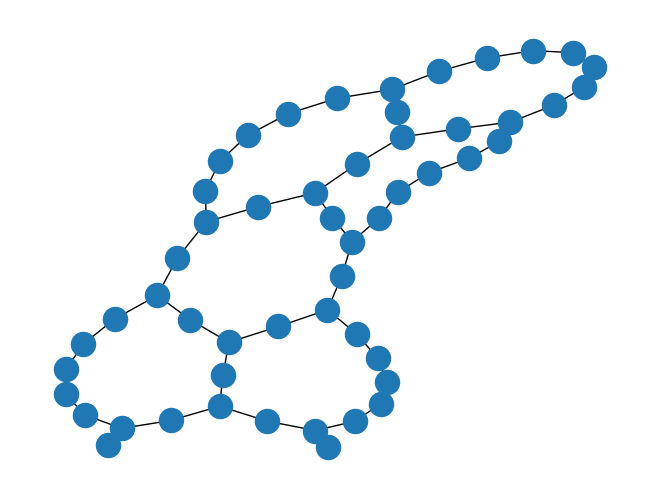

In [2]:
rochester().draw()

### Other available architecture graphs

- IBM Tokyo (20 qubits)
- Google Sycamore (53 qubits)

In [3]:
from architecture import tokyo, sycamore

IBM Tokyo (20 qubits) Quantum Device

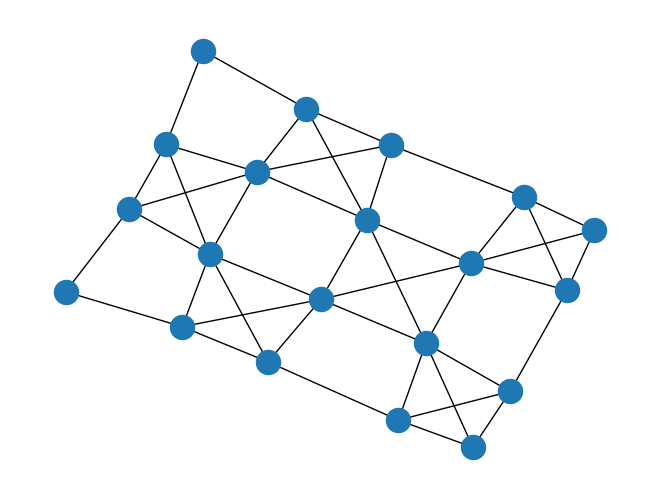

In [4]:
tokyo().draw()

Google Sycamore (53 qubits) Quantum Device

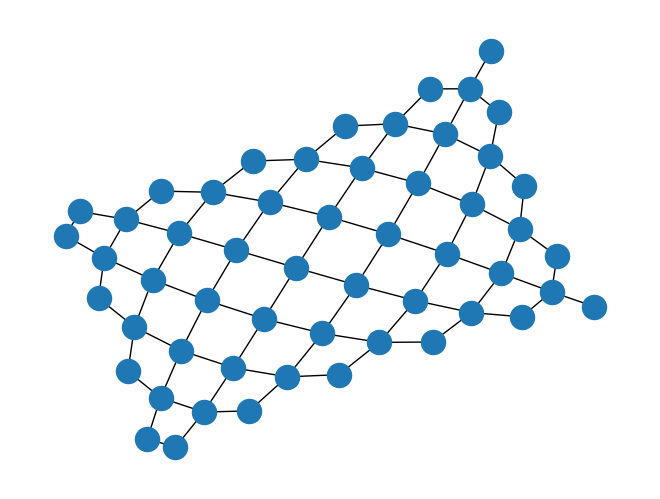

In [5]:
sycamore().draw()